In [2]:
import os
os.chdir("..")

In [3]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import re
import joblib
from collections import defaultdict

In [ ]:
def extract_layer_number(filepath: str) -> int:
    filename = Path(filepath).stem 

    match = re.search(r'layer_(\d+)', filename)

    if match:
        return int(match.group(1))
    else:
        raise ValueError(f"Could not extract layer number from filename: {filepath}")

In [ ]:
probe_base_dir = Path("outputs/probes/logreg/input/meta-llama-Llama-3.2-3B-Instruct")

probes_by_layer = {}
for probe_file in probe_base_dir.glob("*.joblib"):
    layer = extract_layer_number(str(probe_file))
    probe = joblib.load(probe_file)
    probes_by_layer[layer] = probe

In [ ]:
def quick_pred(probe, activations):
    activations = activations.float().numpy()
    scaled_activations = probe["scaler"].transform(activations)
    logits = probe["model"].decision_function(scaled_activations)
    predictions = probe["model"].predict(scaled_activations)
    return predictions, logits

In [ ]:
activations_dir = Path("outputs/cached_activations")

baseline_predictions_by_layer = defaultdict(list)
baseline_logits_by_layer = defaultdict(list)
obfuscated_predictions_by_layer = defaultdict(list)
obfuscated_logits_by_layer = defaultdict(list)

for activation_file in activations_dir.glob("*.pt"):
    baseline_activations, obfuscated_activations = torch.load(activation_file)
    
    baseline_activations.positions = -1
    obfuscated_activations.positions = -1

    baseline_activations = baseline_activations.extract_positions()
    obfuscated_activations = obfuscated_activations.extract_positions()
    
    for layer, _ in baseline_activations:
        probe = probes_by_layer[layer]
        
        baseline_layer_activations = baseline_activations[(layer, "layer_out")]
        baseline_predictions, baseline_logits = quick_pred(probe, baseline_layer_activations)
        
        obfuscated_layer_activations = obfuscated_activations[(layer, "layer_out")]
        obfuscated_predictions, obfuscated_logits = quick_pred(probe, obfuscated_layer_activations)
        
        baseline_predictions_by_layer[layer].append(baseline_predictions)
        baseline_logits_by_layer[layer].append(baseline_logits)
        obfuscated_predictions_by_layer[layer].append(obfuscated_predictions)
        obfuscated_logits_by_layer[layer].append(obfuscated_logits)
        

C:\Users\91967\AppData\Local\Temp\ipykernel_13988\3354136158.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_activations, obfuscated_activations = torch.load(ac

torch.Size([64, 3072])

# Sanity check

In [7]:
# Concatenate predictions across all layers for each datapoint
# baseline_predictions_by_layer[layer] contains a list of prediction arrays (one per activation file)
# We want to average across all layers for each datapoint

# First, let's concatenate predictions across activation files for each layer
baseline_preds_concatenated = {}
obfuscated_preds_concatenated = {}

for layer in sorted(baseline_predictions_by_layer.keys()):
    baseline_preds_concatenated[layer] = np.concatenate(baseline_predictions_by_layer[layer])
    obfuscated_preds_concatenated[layer] = np.concatenate(obfuscated_predictions_by_layer[layer])

print(f"Number of layers: {len(baseline_preds_concatenated)}")
print(f"Number of datapoints per layer: {baseline_preds_concatenated[0].shape}")


Number of layers: 28
Number of datapoints per layer: (128,)


In [8]:
# Now compute the average prediction across all layers for each datapoint
# Stack predictions from all layers (shape: num_layers x num_datapoints)
baseline_preds_stacked = np.stack([baseline_preds_concatenated[layer] for layer in sorted(baseline_preds_concatenated.keys())])
obfuscated_preds_stacked = np.stack([obfuscated_preds_concatenated[layer] for layer in sorted(obfuscated_preds_concatenated.keys())])

# Average across layers (axis=0)
baseline_avg_preds = baseline_preds_stacked.mean(axis=0)
obfuscated_avg_preds = obfuscated_preds_stacked.mean(axis=0)

print(f"Shape of stacked predictions: {baseline_preds_stacked.shape}")
print(f"Shape of averaged predictions: {baseline_avg_preds.shape}")
print(f"\nBaseline average predictions (first 10): {baseline_avg_preds[:10]}")
print(f"Obfuscated average predictions (first 10): {obfuscated_avg_preds[:10]}")


Shape of stacked predictions: (28, 128)
Shape of averaged predictions: (128,)

Baseline average predictions (first 10): [1.         1.         0.92857143 1.         0.96428571 0.92857143
 0.89285714 1.         1.         0.92857143]
Obfuscated average predictions (first 10): [0.03571429 0.03571429 0.         0.         0.03571429 0.03571429
 0.         0.03571429 0.03571429 0.03571429]


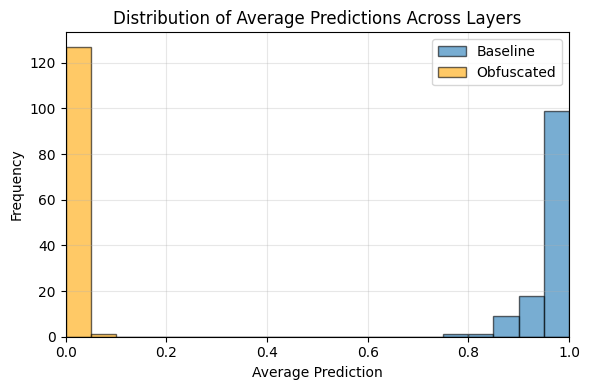


Baseline Statistics:
  Mean: 0.9754
  Std: 0.0430
  Min: 0.7857
  Max: 1.0000

Obfuscated Statistics:
  Mean: 0.0312
  Std: 0.0126
  Min: 0.0000
  Max: 0.0714


In [9]:
# Visualize the distribution of average predictions - merged histogram
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Create bins from 0 to 1 with 20 bins
bins = np.linspace(0, 1, 21)

ax.hist(baseline_avg_preds, bins=bins, alpha=0.6, label='Baseline', edgecolor='black')
ax.hist(obfuscated_avg_preds, bins=bins, alpha=0.6, label='Obfuscated', color='orange', edgecolor='black')
ax.set_xlabel('Average Prediction')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Average Predictions Across Layers')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show statistics
print(f"\nBaseline Statistics:")
print(f"  Mean: {baseline_avg_preds.mean():.4f}")
print(f"  Std: {baseline_avg_preds.std():.4f}")
print(f"  Min: {baseline_avg_preds.min():.4f}")
print(f"  Max: {baseline_avg_preds.max():.4f}")

print(f"\nObfuscated Statistics:")
print(f"  Mean: {obfuscated_avg_preds.mean():.4f}")
print(f"  Std: {obfuscated_avg_preds.std():.4f}")
print(f"  Min: {obfuscated_avg_preds.min():.4f}")
print(f"  Max: {obfuscated_avg_preds.max():.4f}")

## Conclusion

Results matched

# Identify intelligent layers

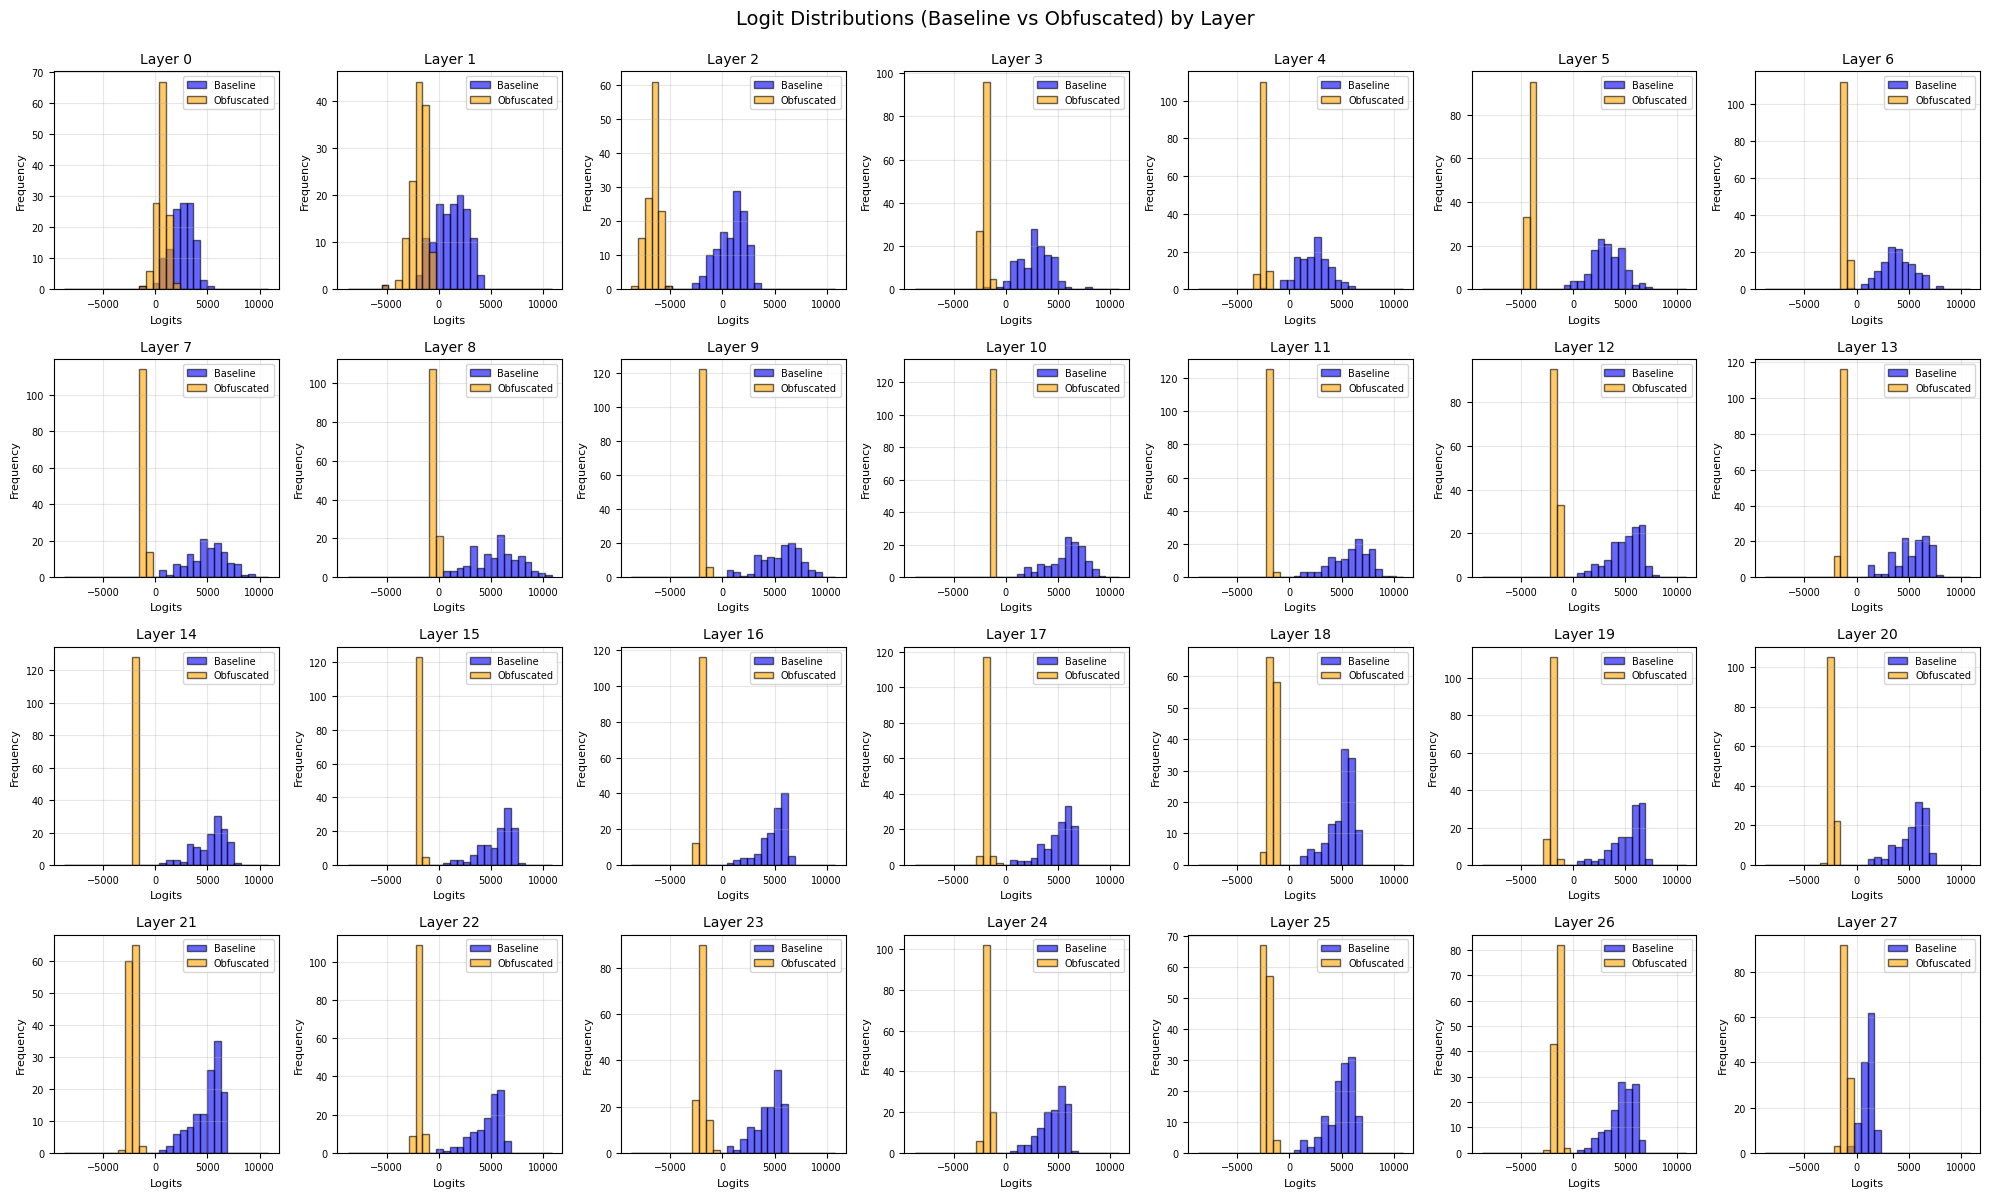

In [10]:
# Concatenate logits across activation files for each layer
baseline_logits_concatenated = {}
obfuscated_logits_concatenated = {}

for layer in sorted(baseline_logits_by_layer.keys()):
    baseline_logits_concatenated[layer] = np.concatenate(baseline_logits_by_layer[layer])
    obfuscated_logits_concatenated[layer] = np.concatenate(obfuscated_logits_by_layer[layer])

# Create 4x7 grid of histograms showing baseline and obfuscated logits at each layer
num_layers = len(baseline_logits_concatenated)
fig, axes = plt.subplots(4, 7, figsize=(20, 12))
axes = axes.flatten()

# Determine global min/max for consistent binning across all layers
all_baseline_logits = np.concatenate([baseline_logits_concatenated[layer] for layer in sorted(baseline_logits_concatenated.keys())])
all_obfuscated_logits = np.concatenate([obfuscated_logits_concatenated[layer] for layer in sorted(obfuscated_logits_concatenated.keys())])
global_min = min(all_baseline_logits.min(), all_obfuscated_logits.min())
global_max = max(all_baseline_logits.max(), all_obfuscated_logits.max())
bins = np.linspace(global_min, global_max, 31)

for idx, layer in enumerate(sorted(baseline_logits_concatenated.keys())):
    if idx >= 28:  # Only plot first 28 layers (4x7 grid)
        break
    
    ax = axes[idx]
    
    # Plot both baseline and obfuscated logits with same bins
    ax.hist(baseline_logits_concatenated[layer], bins=bins, alpha=0.6, label='Baseline', edgecolor='black', color='blue')
    ax.hist(obfuscated_logits_concatenated[layer], bins=bins, alpha=0.6, label='Obfuscated', edgecolor='black', color='orange')
    
    ax.set_title(f'Layer {layer}', fontsize=10)
    ax.set_xlabel('Logits', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

# Hide any unused subplots
for idx in range(num_layers, 28):
    axes[idx].axis('off')

plt.suptitle('Logit Distributions (Baseline vs Obfuscated) by Layer', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

## Conclusion (Assuming the probes are picking up on meaningful signals)

* Some separation observed at layer 0
  * Maybe certain tokens/ are considered harmful?
* Based on probe similarities plot, layers 2, 12, 20 warrant additional investigation